# Análise de Dados — PNAD COVID-19
## Como se preparar diante de uma nova pandemia?

Este estudo analisa dados da pesquisa **PNAD COVID-19 (IBGE)** com o objetivo de identificar padrões e indicadores que auxiliem hospitais e gestores de saúde pública no **planejamento estratégico para futuros surtos pandêmicos**.

Os dados cobrem os meses de **maio a novembro de 2020** e abordam:
- Sintomas reportados pela população
- Busca por atendimento médico
- Tipos de estabelecimentos de saúde utilizados
- Taxas de internação
- Realização de testes diagnósticos

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

MESES_LABELS = ['Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov']

# Carregar todos os CSVs
df_sintomas = pd.read_csv('csv/B1_sintomas.csv')
df_atendimento = pd.read_csv('csv/B2_procurou_atendimento.csv')
df_estabelecimentos = pd.read_csv('csv/B4_estabelecimentos_saude.csv')
df_internacoes = pd.read_csv('csv/B5_internacoes.csv')
df_testes = pd.read_csv('csv/B8_fez_teste.csv')

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


---
## 1. Evolução dos Sintomas ao Longo do Tempo

Compreender quais sintomas são mais prevalentes e como evoluem ao longo dos meses é essencial para:
- **Triagem rápida**: definir protocolos de atendimento baseados nos sintomas mais frequentes
- **Planejamento de insumos**: estoque de medicamentos direcionados aos sintomas dominantes
- **Alertas epidemiológicos**: picos de determinados sintomas podem sinalizar novas ondas

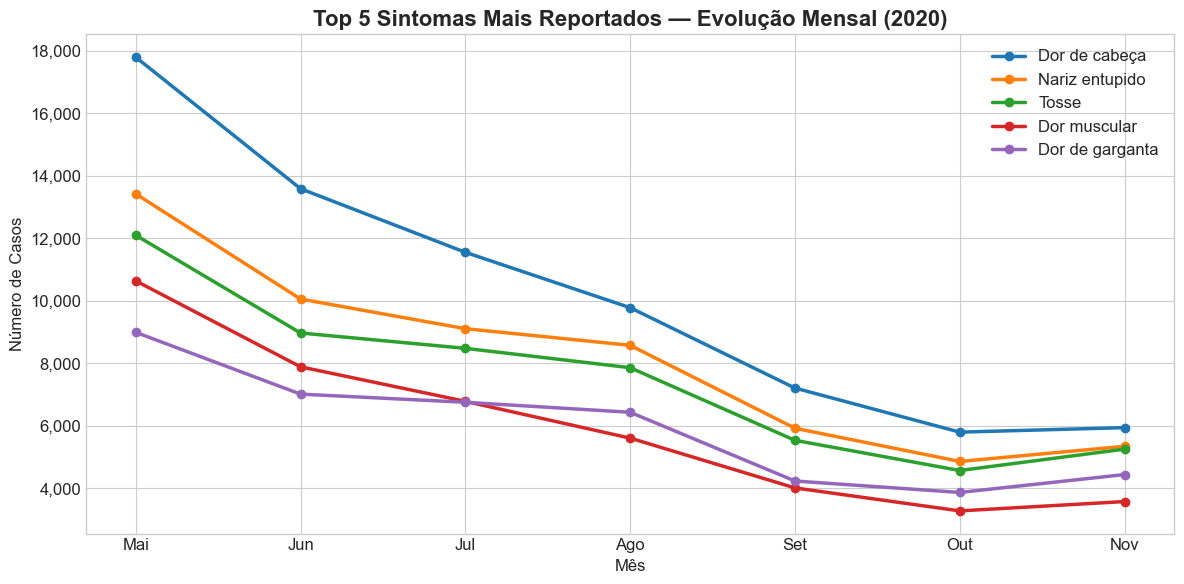

In [ ]:
# Gráfico 1 — Top 5 sintomas mais reportados (evolução mensal)
sintomas_cols = df_sintomas.columns[1:]  # todas exceto 'mes'
totais = df_sintomas[sintomas_cols].sum().sort_values(ascending=False)

top5 = totais.head(5).index.tolist()

labels_sintomas = {
    'casos_dor_cabeca': 'Dor de cabeça',
    'casos_nariz_entupido': 'Nariz entupido',
    'casos_tosse': 'Tosse',
    'casos_dor_garganta': 'Dor de garganta',
    'casos_dor_muscular': 'Dor muscular',
    'casos_febre': 'Febre',
    'casos_fadiga_cansaco': 'Fadiga/Cansaço',
    'casos_perda_cheiro_sabor': 'Perda de cheiro/sabor',
    'casos_dificuldade_respirar': 'Dificuldade respirar',
    'casos_dor_peito': 'Dor no peito',
    'casos_nausea': 'Náusea',
    'casos_dor_olhos': 'Dor nos olhos',
    'casos_diarreia': 'Diarreia'
}

fig, ax = plt.subplots(figsize=(12, 6))
for col in top5:
    ax.plot(MESES_LABELS, df_sintomas[col], marker='o', linewidth=2.5, label=labels_sintomas.get(col, col))

ax.set_title('Top 5 Sintomas Mais Reportados — Evolução Mensal (2020)', fontsize=16, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Número de Casos')
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

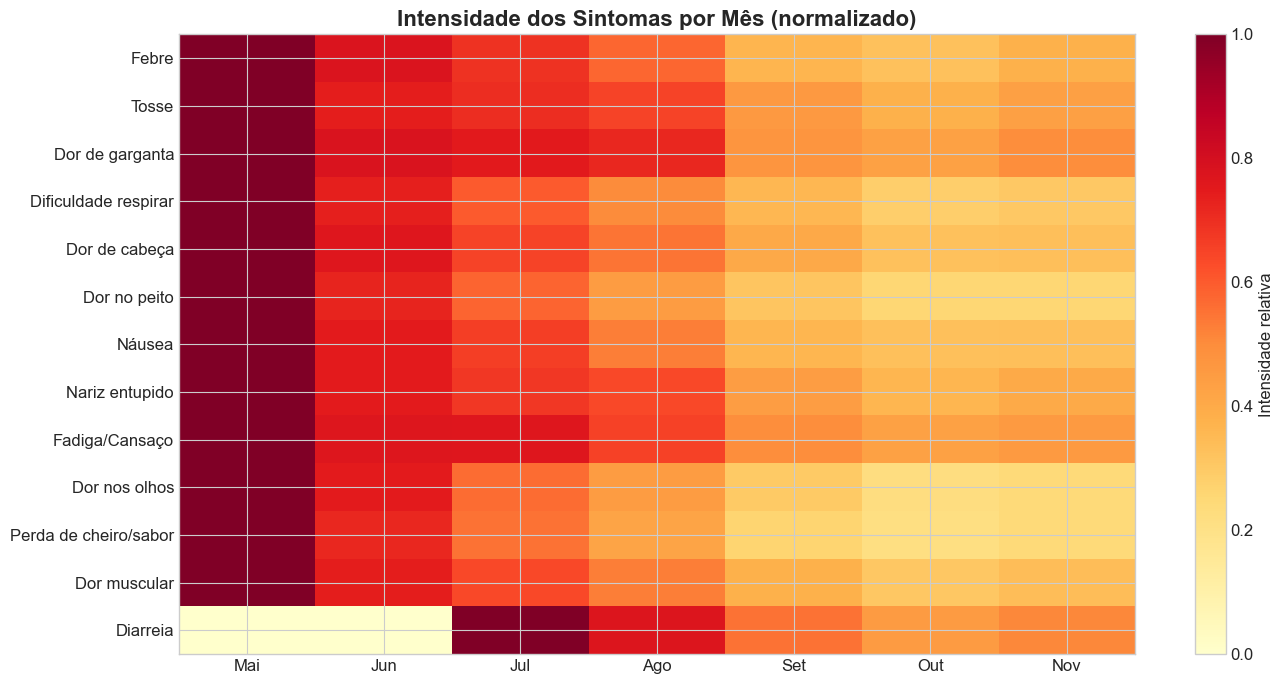

In [ ]:
# Gráfico 2 — Heatmap de todos os sintomas por mês
import numpy as np

sintomas_norm = df_sintomas[sintomas_cols].copy()
sintomas_norm = sintomas_norm.div(sintomas_norm.max(axis=0), axis=1)  # normalizar 0-1 por sintoma

fig, ax = plt.subplots(figsize=(14, 7))
sintomas_display = [labels_sintomas.get(c, c) for c in sintomas_cols]

im = ax.imshow(sintomas_norm.T.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(MESES_LABELS)))
ax.set_xticklabels(MESES_LABELS)
ax.set_yticks(range(len(sintomas_display)))
ax.set_yticklabels(sintomas_display)
ax.set_title('Intensidade dos Sintomas por Mês (normalizado)', fontsize=16, fontweight='bold')
plt.colorbar(im, ax=ax, label='Intensidade relativa')
plt.tight_layout()
plt.show()

### Insight — Sintomas

**Dor de cabeça** e **nariz entupido** foram consistentemente os sintomas mais reportados, seguidos por **tosse** e **dor muscular**. Todos apresentam tendência de queda entre maio e outubro, com leve alta em novembro.

**Recomendação para preparação:**
- Protocolo de triagem deve priorizar sintomas respiratórios superiores (nariz, garganta, tosse)
- Manter estoque de analgésicos e antitérmicos como prioridade
- Monitorar reversão de tendência de queda como sinal de alerta de nova onda

---
## 2. Busca por Atendimento Médico

Entender a proporção de sintomáticos que buscam atendimento ajuda a:
- Dimensionar a **demanda esperada** nos serviços de saúde
- Identificar potenciais **subnotificações** (quem tem sintoma mas não busca atendimento)

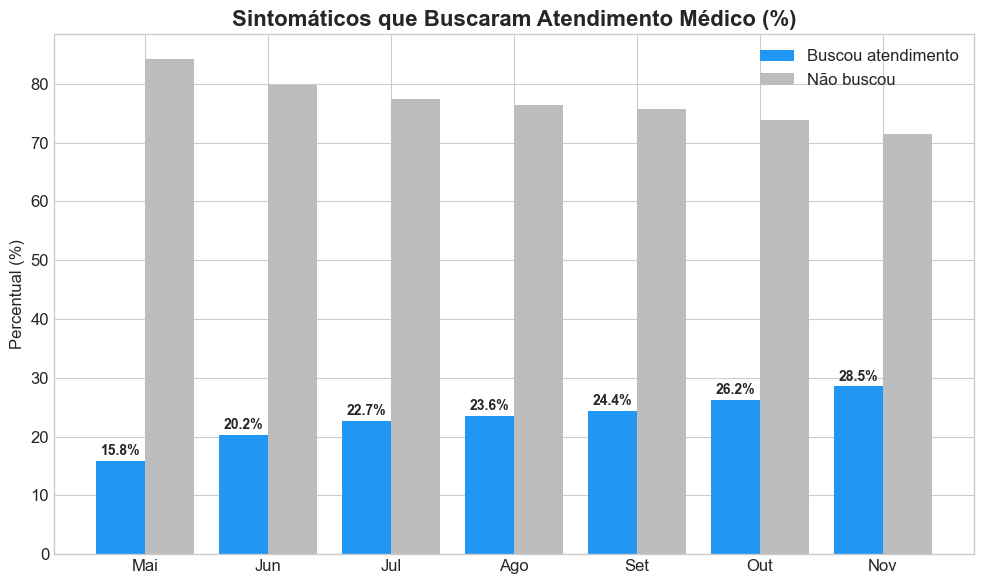

In [ ]:
# Gráfico 3 — Proporção que buscou atendimento ao longo dos meses
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.4
x = np.arange(len(MESES_LABELS))

ax.bar(x - bar_width/2, df_atendimento['pct_sim'], bar_width, label='Buscou atendimento', color='#2196F3')
ax.bar(x + bar_width/2, df_atendimento['pct_nao'], bar_width, label='Não buscou', color='#BDBDBD')

ax.set_xticks(x)
ax.set_xticklabels(MESES_LABELS)
ax.set_ylabel('Percentual (%)')
ax.set_title('Sintomáticos que Buscaram Atendimento Médico (%)', fontsize=16, fontweight='bold')
ax.legend()

# Anotação nos valores de "sim"
for i, v in enumerate(df_atendimento['pct_sim']):
    ax.text(i - bar_width/2, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Insight — Busca por Atendimento

A proporção de sintomáticos que buscou atendimento **cresceu progressivamente** de ~16% em maio para ~29% em novembro. Isso pode indicar:
- Maior conscientização da população ao longo do tempo
- Melhora no acesso aos serviços de saúde
- Aumento da gravidade percebida dos sintomas

**Recomendação para preparação:**
- Nos primeiros meses de uma pandemia, investir em **campanhas de conscientização** para incentivar a busca por atendimento precoce
- Planejar capacidade hospitalar considerando que a demanda tende a **crescer com o tempo**, não diminuir

---
## 3. Estabelecimentos de Saúde Mais Procurados

Mapear onde a população busca atendimento é crucial para **alocar recursos** de forma inteligente.

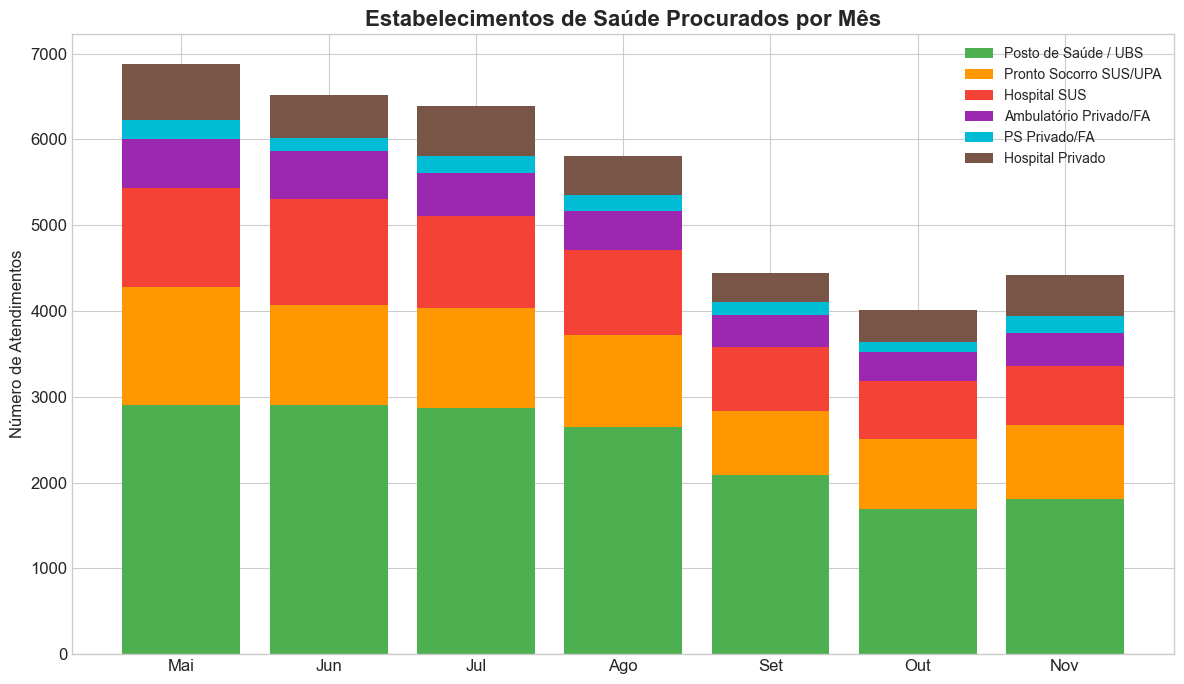

In [8]:
# Gráfico 4 — Distribuição por tipo de estabelecimento (barras empilhadas)
estab_cols = df_estabelecimentos.columns[1:]
labels_estab = {
    'casos_posto_saude': 'Posto de Saúde / UBS',
    'casos_pronto_socorro': 'Pronto Socorro SUS/UPA',
    'casos_hospital_sus_upa': 'Hospital SUS',
    'casos_ambulatorio_forcas_armadas': 'Ambulatório Privado/FA',
    'casos_pronto_socorro_forcas_armadas': 'PS Privado/FA',
    'casos_hospital_privado': 'Hospital Privado'
}

fig, ax = plt.subplots(figsize=(12, 7))
bottom = np.zeros(len(MESES_LABELS))
colors = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4', '#795548']

for i, col in enumerate(estab_cols):
    values = df_estabelecimentos[col].values
    ax.bar(MESES_LABELS, values, bottom=bottom, label=labels_estab.get(col, col), color=colors[i])
    bottom += values

ax.set_title('Estabelecimentos de Saúde Procurados por Mês', fontsize=16, fontweight='bold')
ax.set_ylabel('Número de Atendimentos')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

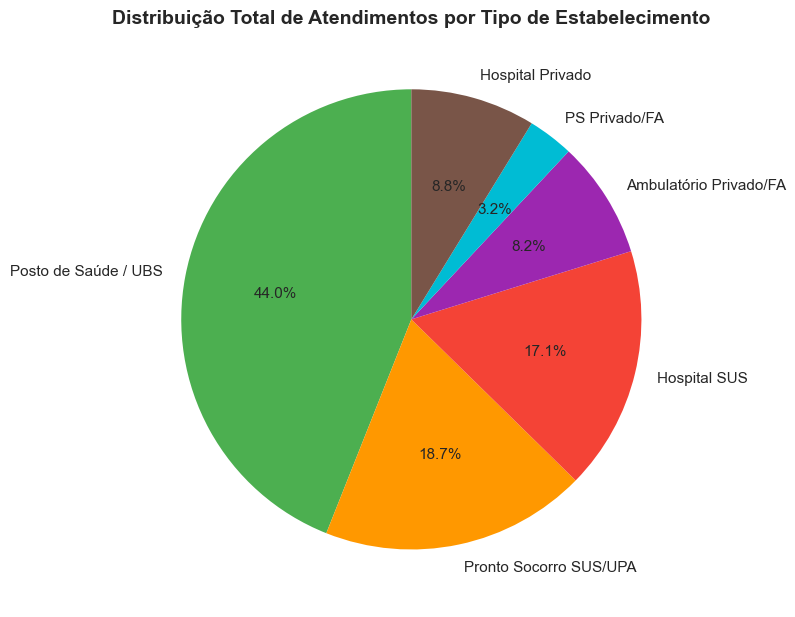

In [ ]:
# Gráfico 5 — Participação percentual de cada tipo de estabelecimento
estab_total = df_estabelecimentos[estab_cols].sum()
estab_pct = (estab_total / estab_total.sum()) * 100

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    estab_pct.values,
    labels=[labels_estab.get(c, c) for c in estab_cols],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11}
)
ax.set_title('Distribuição Total de Atendimentos por Tipo de Estabelecimento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight — Estabelecimentos de Saúde

Os **Postos de Saúde / UBS** foram o principal ponto de atendimento, seguidos por **Pronto Socorros** e **Hospitais SUS**. O setor público absorveu a maior parte da demanda.

**Recomendação para preparação:**
- **Atenção primária (UBS)** deve ser o foco principal de investimento e expansão de capacidade
- Treinar equipes de UBS para triagem e manejo inicial de doenças respiratórias
- Criar protocolos de encaminhamento eficientes entre UBS → UPA → Hospital

---
## 4. Taxas de Internação

As taxas de internação indicam a **gravidade dos casos** e ajudam no dimensionamento de **leitos hospitalares**.

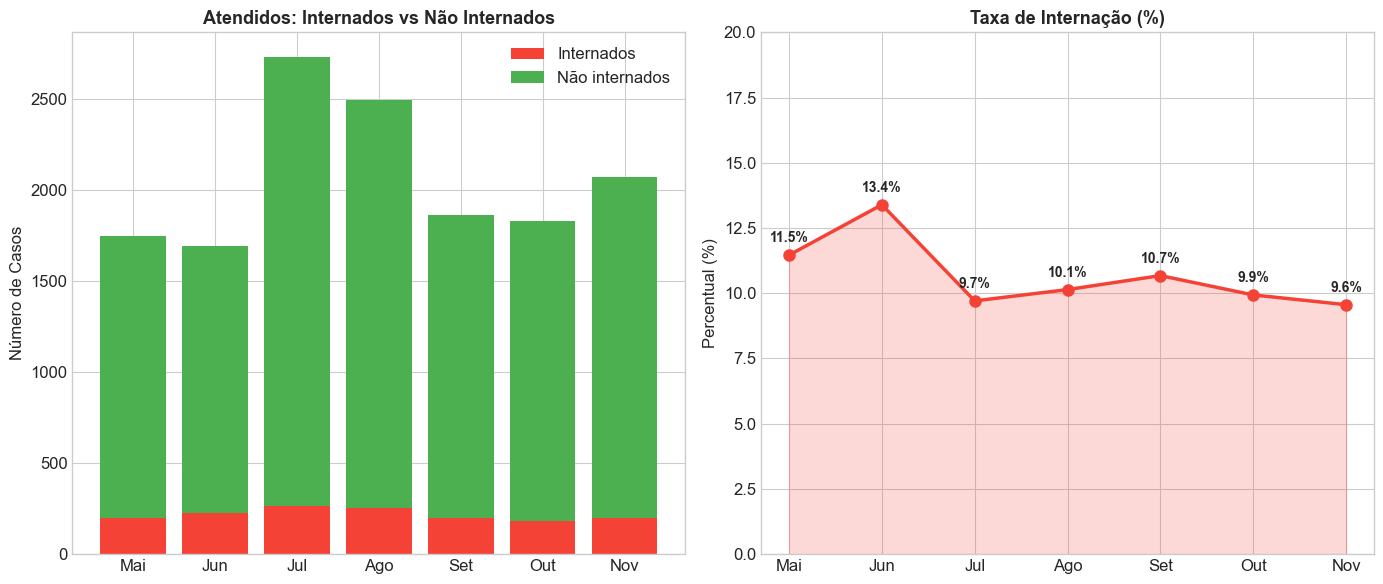

In [ ]:
# Gráfico 6 — Evolução da taxa de internação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Painel esquerdo: números absolutos
ax1.bar(MESES_LABELS, df_internacoes['casos_internado'], color='#F44336', label='Internados')
ax1.bar(MESES_LABELS, df_internacoes['casos_nao_internado'], bottom=df_internacoes['casos_internado'],
        color='#4CAF50', label='Não internados')
ax1.set_title('Atendidos: Internados vs Não Internados', fontsize=13, fontweight='bold')
ax1.set_ylabel('Número de Casos')
ax1.legend()

# Painel direito: percentual de internação
ax2.plot(MESES_LABELS, df_internacoes['pct_internado'], marker='o', color='#F44336',
         linewidth=2.5, markersize=8)
ax2.fill_between(range(len(MESES_LABELS)), df_internacoes['pct_internado'], alpha=0.2, color='#F44336')
ax2.set_title('Taxa de Internação (%)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Percentual (%)')
ax2.set_ylim(0, 20)

for i, v in enumerate(df_internacoes['pct_internado']):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Insight — Internações

A taxa de internação oscilou entre **~10% e ~13%** dos que buscaram atendimento. O pico ocorreu em junho (~13.4%), coincidindo com o início mais intenso da pandemia no Brasil.

**Recomendação para preparação:**
- Planejar **10-15% de leitos adicionais** em relação à demanda estimada de atendimento
- Manter planos de contingência para expansão rápida de leitos (hospitais de campanha)
- A taxa relativamente estável sugere que o dimensionamento pode ser feito com base na demanda esperada

---
## 5. Testagem

A capacidade de testagem é um dos pilares fundamentais no combate a pandemias.

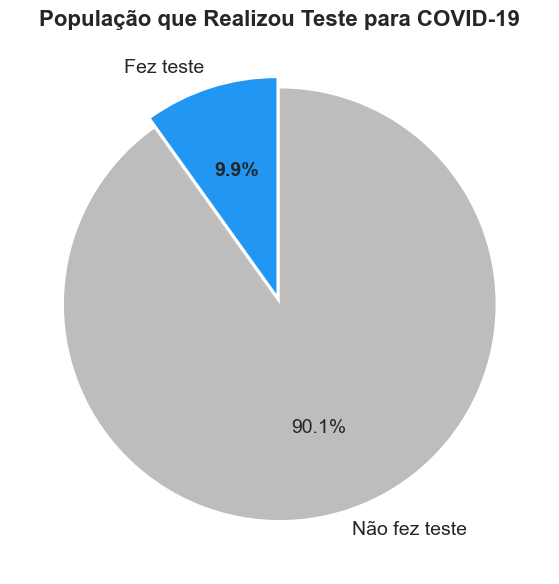

Total que fez teste: 188,927
Total que NÃO fez teste: 1,724,584


In [ ]:
# Gráfico 7 — Proporção geral de testados vs não testados
fig, ax = plt.subplots(figsize=(8, 6))

labels_teste = ['Fez teste', 'Não fez teste']
valores = [df_testes['pct_sim'].values[0], df_testes['pct_nao'].values[0]]
colors_teste = ['#2196F3', '#BDBDBD']

wedges, texts, autotexts = ax.pie(
    valores,
    labels=labels_teste,
    autopct='%1.1f%%',
    colors=colors_teste,
    startangle=90,
    explode=(0.05, 0),
    textprops={'fontsize': 14}
)
autotexts[0].set_fontweight('bold')
ax.set_title('População que Realizou Teste para COVID-19', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total que fez teste: {df_testes['total_sim'].values[0]:,}")
print(f"Total que NÃO fez teste: {df_testes['total_nao'].values[0]:,}")

### Insight — Testagem

Apenas **~9.9%** da população realizou teste para COVID-19. Isso revela uma **enorme lacuna na testagem**, o que compromete:
- A capacidade de rastreamento de contatos
- A precisão dos dados epidemiológicos
- A eficácia de medidas de isolamento

**Recomendação para preparação:**
- Investir em **infraestrutura de testagem em massa** desde o início de um surto
- Distribuir testes rápidos nas UBS (principal ponto de atendimento)
- Criar sistemas de notificação digital para agilizar o rastreamento de contatos

---
## 6. Visão Consolidada e Recomendações Estratégicas

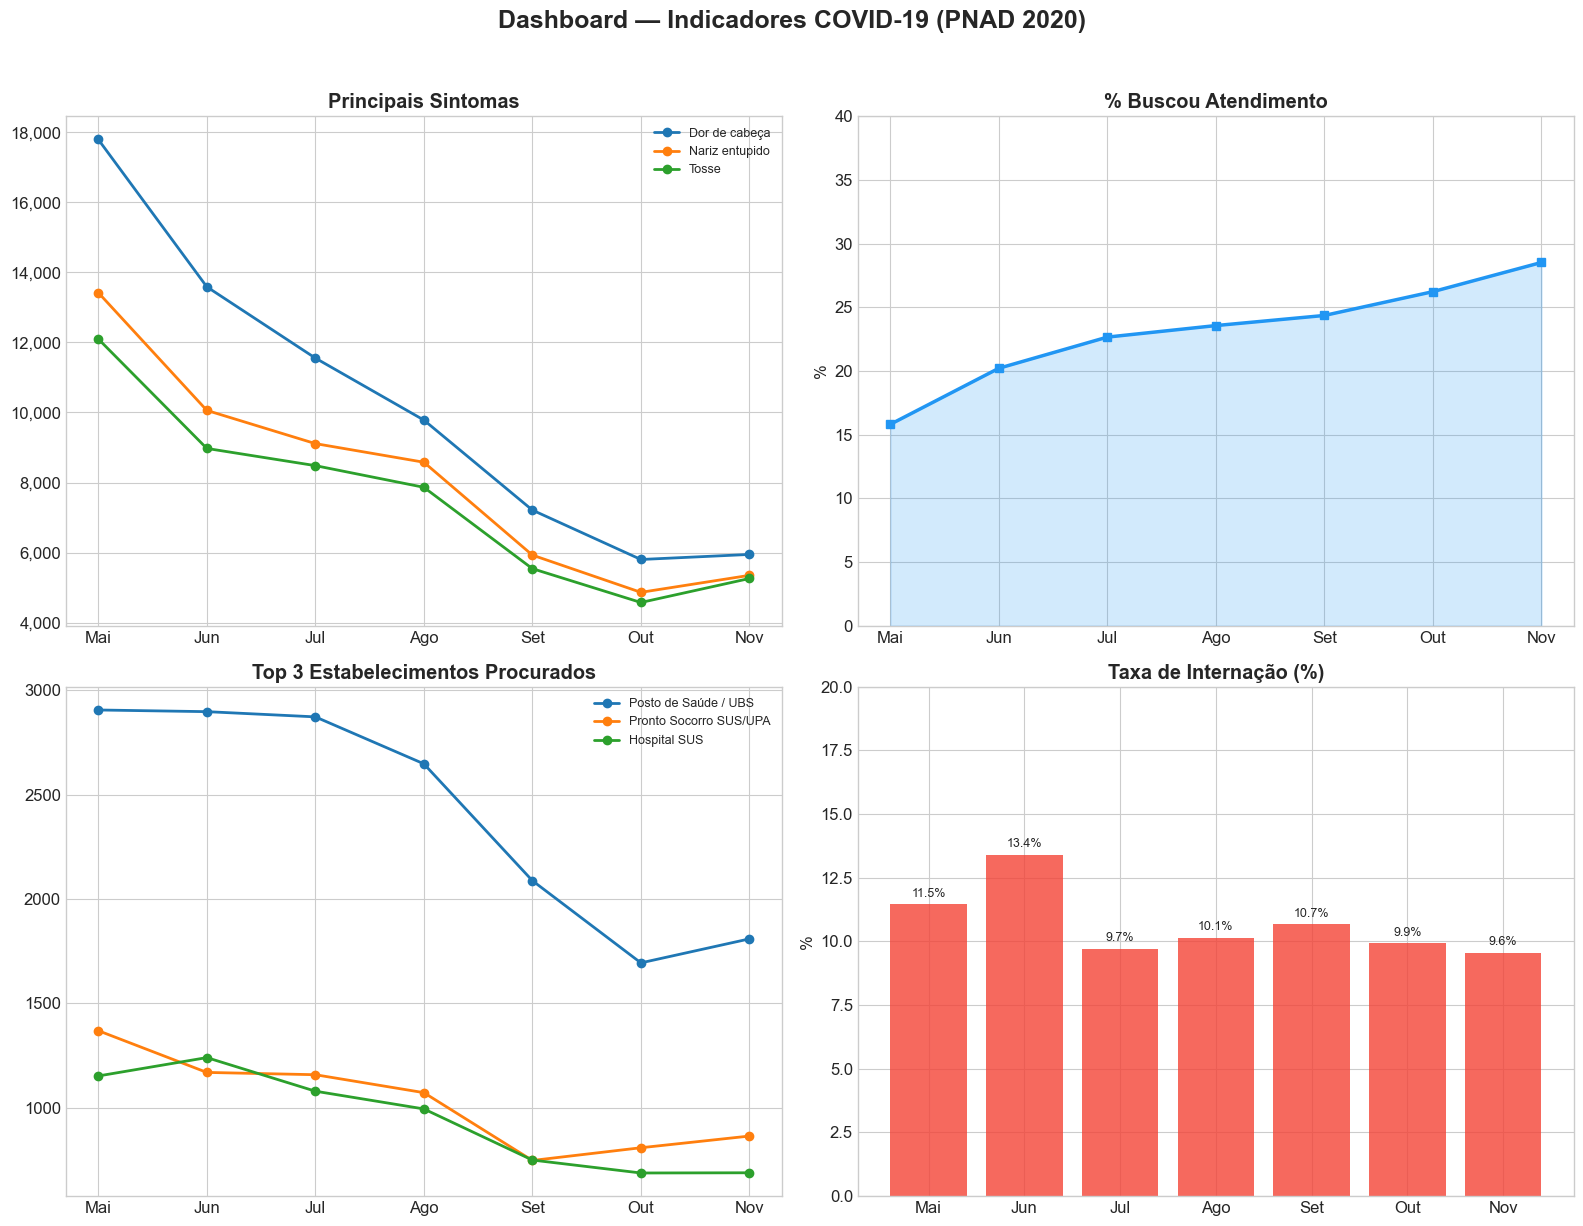

In [12]:
# Gráfico 8 — Dashboard consolidado com indicadores-chave
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Tendência dos principais sintomas
ax = axes[0, 0]
for col in top5[:3]:
    ax.plot(MESES_LABELS, df_sintomas[col], marker='o', linewidth=2, label=labels_sintomas.get(col, col))
ax.set_title('Principais Sintomas', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Top-right: Busca por atendimento
ax = axes[0, 1]
ax.plot(MESES_LABELS, df_atendimento['pct_sim'], marker='s', color='#2196F3', linewidth=2.5)
ax.fill_between(range(len(MESES_LABELS)), df_atendimento['pct_sim'], alpha=0.2, color='#2196F3')
ax.set_title('% Buscou Atendimento', fontweight='bold')
ax.set_ylabel('%')
ax.set_ylim(0, 40)

# Bottom-left: Estabelecimentos (só os 3 maiores)
ax = axes[1, 0]
top3_estab = ['casos_posto_saude', 'casos_pronto_socorro', 'casos_hospital_sus_upa']
for col in top3_estab:
    ax.plot(MESES_LABELS, df_estabelecimentos[col], marker='o', linewidth=2,
            label=labels_estab.get(col, col))
ax.set_title('Top 3 Estabelecimentos Procurados', fontweight='bold')
ax.legend(fontsize=9)

# Bottom-right: Taxa de internação
ax = axes[1, 1]
ax.bar(MESES_LABELS, df_internacoes['pct_internado'], color='#F44336', alpha=0.8)
ax.set_title('Taxa de Internação (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_ylim(0, 20)
for i, v in enumerate(df_internacoes['pct_internado']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

fig.suptitle('Dashboard — Indicadores COVID-19 (PNAD 2020)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Conclusão — Plano de Preparação para Novas Pandemias

Com base na análise dos dados da PNAD COVID-19, recomendamos as seguintes **ações estratégicas** para hospitais e gestores de saúde:

### 1. Vigilância Epidemiológica
- Monitorar **sintomas respiratórios superiores** (dor de cabeça, congestão nasal, tosse) como indicadores precoces
- Criar sistemas de alerta baseados em reversão de tendências de queda nos sintomas

### 2. Capacidade de Atendimento
- Fortalecer a **atenção primária (UBS/Postos de Saúde)**, que absorve a maior demanda
- Planejar para uma demanda de atendimento que **cresce ao longo do tempo** (de ~16% para ~29%)
- Manter protocolos claros de referência entre UBS → UPA → Hospital

### 3. Leitos e Internação
- Reservar capacidade para **10-15% de internação** entre os que buscam atendimento
- Ter planos de contingência para ativação rápida de leitos adicionais

### 4. Testagem
- **Ampliar massivamente** a capacidade de testagem — apenas ~10% da população foi testada
- Distribuir testes rápidos nos pontos de atendimento primário
- Implementar rastreamento digital de contatos

### 5. Comunicação e Conscientização
- Investir em campanhas para **incentivar a busca precoce por atendimento**
- Educar a população sobre sintomas de alerta e quando procurar ajuda médica

---
*Estudo desenvolvido com dados da PNAD COVID-19 (IBGE) — Projeto FIAP*